## Alteracoes para acelerar o treino e a inferencia

- **Resolucao**: `img_height`/`img_width` reduzidos de 61 para 32 (a tarefa e classificar a cor de fundo predominante, nao reconhecer a letra -- o fundo ocupa ~83% dos pixels em uma amostra real).
- **`interpolation="area"`**: reamostragem mais adequada para reduzir imagens (evita aliasing); o mesmo metodo foi usado em `compvision.py` para manter treino e inferencia consistentes.
- **`Flatten()` -> `GlobalAveragePooling2D()`**: elimina a camada `Dense` gigante que vinha do flatten (a maior parte dos parametros do modelo) sem perder informacao relevante para classificar cor.
- **`EarlyStopping`**: interrompe o treino quando a acuracia de validacao para de melhorar, em vez de sempre rodar todas as epocas.

**Depois de rodar este notebook, `modelo.keras` tera uma arquitetura nova -- e preciso treinar de novo antes de usar com `compvision.py`** (que tambem foi atualizado para esperar entradas 32x32).

In [104]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf
import pathlib

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [105]:
data_dir = pathlib.Path("../data/images/")

In [106]:
image_count = len(list(data_dir.glob('*/*.png')))
print('Total de imagens:', image_count)

# Contagem por classe -- se uma pasta tiver muito mais imagens que as
# outras (desbalanceamento), ou se o total for muito pequeno, o
# modelo pode aprender a so prever a classe majoritaria em vez de
# realmente distinguir as cores.
for pasta in sorted(p for p in data_dir.iterdir() if p.is_dir()):
    n = len(list(pasta.glob('*.png')))
    print(f'  {pasta.name}: {n} imagens')

Total de imagens: 78
  amarelo: 26 imagens
  preto: 26 imagens
  verde: 26 imagens


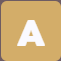

In [107]:
yellow = list(data_dir.glob('amarelo/*'))
PIL.Image.open(str(yellow[0]))

In [108]:
# batch_size pequeno de proposito: com poucas imagens por classe
# (letras x 3 cores costuma dar um dataset pequeno), um batch grande
# significa POUCAS atualizacoes de peso por epoca -- o modelo pode
# parecer 'nao aprender' so porque quase nao deu passos de gradiente,
# nao porque a tarefa seja dificil. Ajuste para cima com cuidado e so
# se a contagem de imagens (celula acima) mostrar um dataset grande.
batch_size = 8
# Resolucao reduzida (61 -> 32): a tarefa e classificar a COR de fundo
# do quadrado (amarelo/preto/verde), nao reconhecer a letra. Na imagem
# de amostra enviada, o fundo ja ocupa ~83% dos pixels, entao uma
# resolucao bem menor preserva o sinal relevante e acelera tanto o
# treino (menos pixels por convolucao) quanto a inferencia. Se a
# acuracia cair ao testar, aumente de volta (ex.: 48) e retreine.
img_height = 32
img_width = 32

In [109]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  interpolation="area",
  batch_size=batch_size)

Found 78 files belonging to 3 classes.
Using 63 files for training.


In [110]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  interpolation="area",
  batch_size=batch_size)

Found 78 files belonging to 3 classes.
Using 15 files for validation.


In [111]:
class_names = train_ds.class_names
print(class_names)

['amarelo', 'preto', 'verde']


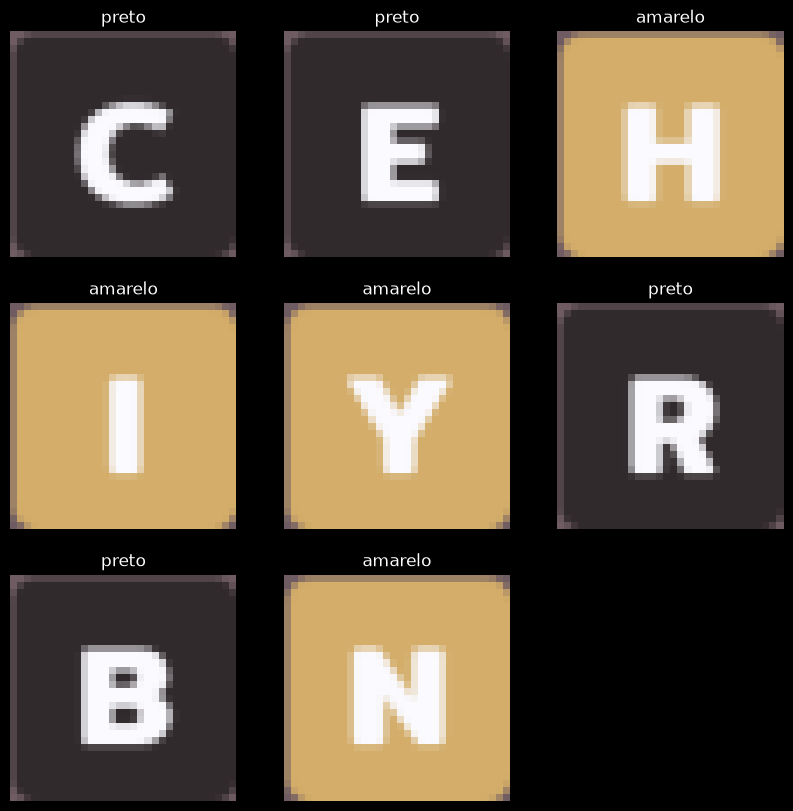

In [112]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  # min(9, ...) em vez de 9 fixo: com batch_size pequeno (agora 8), o
  # lote pode ter menos de 9 imagens.
  n_exemplos = min(9, images.shape[0])
  for i in range(n_exemplos):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [113]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(8, 32, 32, 3)
(8,)


In [114]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [115]:
normalization_layer = layers.Rescaling(1./255)

In [116]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

0.36078435 1.0000001


In [117]:
num_classes = len(class_names)

# Flatten() -> GlobalAveragePooling2D(): o Flatten() gerava um vetor
# gigante (H x W x canais) alimentando a camada Dense seguinte, que
# concentrava a maior parte dos parametros (e do tempo de computacao)
# do modelo inteiro. GlobalAveragePooling2D reduz cada mapa de ativacao
# a um unico valor (a media) -- o que faz sentido aqui, ja que estamos
# classificando uma cor de fundo predominante, nao uma forma -- e
# derruba drasticamente o numero de parametros da camada Dense sem
# perder a informacao relevante para essa tarefa.
#
# RandomRotation/RandomTranslation/RandomZoom: com so ~26 imagens por
# classe (78 no total), o modelo ve os MESMOS exemplos em toda epoca,
# o que favorece decorar em vez de generalizar. Essas camadas aplicam
# pequenas variacoes aleatorias (so durante o treino -- na inferencia
# via predict()/tf.function elas nao fazem nada) para o modelo ver
# cada imagem de um jeito um pouco diferente a cada epoca. Os valores
# sao propositalmente pequenos para nao alterar muito a proporcao da
# cor de fundo, que e o que importa para essa tarefa.
model = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.RandomRotation(0.05),
  layers.RandomTranslation(0.08, 0.08),
  layers.RandomZoom(0.08),
  layers.Conv2D(8, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.GlobalAveragePooling2D(),
  layers.Dense(16, activation='relu'),
  layers.Dense(num_classes)
])

In [118]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [119]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_9 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 8)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 419 (1.64 KB)

 Trainable params: 419 (1.64 KB)

 Non-trainable params: 0 (0.00 B)

In [120]:
import time

epochs = 40
# monitor="val_loss" em vez de "val_accuracy": com um conjunto de
# validacao pequeno (~15 imagens), a acuracia so pode assumir poucos
# valores possiveis (multiplos de 1/15) e fica "presa" nesses saltos
# por varias epocas mesmo com o modelo melhorando de verdade por
# baixo. val_loss e continuo e reflete a evolucao real do treino de
# forma mais confiavel nesse cenario.
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=8,
    restore_best_weights=True,
)

inicio = time.time()
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  callbacks=[early_stopping]
)
print(f"Tempo total de treino: {time.time() - inicio:.1f}s ({len(history.epoch)} epocas)")
print("accuracy por epoca:", [round(a, 3) for a in history.history['accuracy']])
print("val_accuracy por epoca:", [round(a, 3) for a in history.history['val_accuracy']])
print("val_loss por epoca:", [round(a, 3) for a in history.history['val_loss']])

Epoch 1/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 245ms/step - accuracy: 0.1905 - loss: 1.0888 - val_accuracy: 0.0000e+00 - val_loss: 1.1091
Epoch 2/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3175 - loss: 1.0514 - val_accuracy: 0.2000 - val_loss: 1.0790
Epoch 3/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3651 - loss: 1.0223 - val_accuracy: 0.2000 - val_loss: 1.0480
Epoch 4/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3651 - loss: 0.9911 - val_accuracy: 0.2000 - val_loss: 1.0207
Epoch 5/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3968 - loss: 0.9556 - val_accuracy: 0.3333 - val_loss: 0.9901
Epoch 6/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6032 - loss: 0.9156 - val_accuracy: 0.5333 - val_loss: 0.9661
Epoch 7/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6667 - loss: 0.8791 - val_accuracy: 0.6000 - val_loss: 0.9398
Epoch 8/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6825 - loss: 0.8417 - val_accuracy: 0.6000 - val_loss: 0.

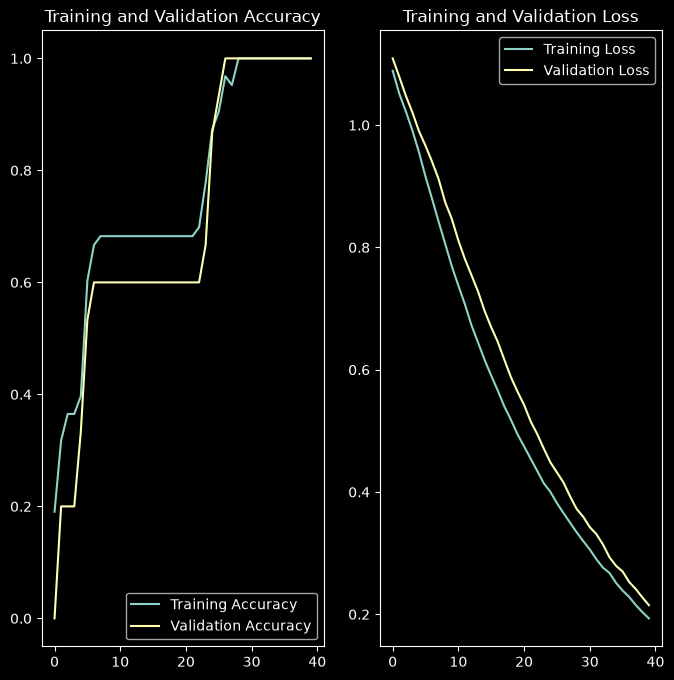

In [121]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

# range(epochs) supunha que o treino sempre rodaria todas as epocas do
# teto (epochs=30). Com EarlyStopping o treino pode parar antes disso,
# entao o eixo x precisa refletir quantas epocas rodaram de fato.
epochs_range = range(len(acc))

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [123]:
caminho_imagem = pathlib.Path("../data/images/amarelo/a.png")
img = tf.keras.utils.load_img(caminho_imagem, target_size=(img_height, img_width))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

previsoes = model.predict(img_array)
print(previsoes)
model.save("modelo.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
[[ 1.6197517 -0.6830659 -5.2836943]]
